# ========================================================================================
#                OPTIMIZACIÓN DE HIPERPARÁMETROS CON GRIDSEARCHCV
# ========================================================================================
# 
# OBJETIVO:
#   Mejorar el rendimiento de los modelos Random Forest ajustando sus hiperparámetros.
#   La rúbrica exige el uso de GridSearchCV o RandomizedSearchCV (IEE 2.3.1).
#
# ¿QUÉ SON LOS HIPERPARÁMETROS?
#   Son "configuraciones" del modelo que NO se aprenden de los datos, sino que 
#   las definimos nosotros antes de entrenar. Ejemplos:
#   - n_estimators: cantidad de árboles en el Random Forest
#   - max_depth: profundidad máxima de cada árbol
#   - min_samples_split: mínimo de muestras para dividir un nodo
#
# ¿QUÉ HACE GRIDSEARCHCV?
#   Prueba TODAS las combinaciones posibles de hiperparámetros que le damos,
#   entrena un modelo con cada combinación, y se queda con la mejor según una métrica.
#   Además, usa Validación Cruzada (CV) para que la evaluación sea robusta.
#
# NOTA: Este proceso puede tomar unos minutos porque entrena múltiples modelos.
# ========================================================================================

# Librerias

In [8]:
import sys
sys.path.insert(0, "..")
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_preprocessing import load_clean_data, merge_tables, create_targets, prepare_features, prepare_regression_data, FEATURES
from src.hyperparameter_tuning import optimize_classifier, optimize_regressor, PARAM_GRID_CLF, PARAM_GRID_REG
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import f1_score, mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc


# Cargar y preparar datos

In [9]:
envios = pd.read_csv('../data/envios_limpio.csv')
incidencias = pd.read_csv('../data/incidencias_limpio.csv')
rutas = pd.read_csv('../data/rutas_limpio.csv')
vehiculos = pd.read_csv('../data/vehiculos_limpio.csv')

print(f"   Envíos: {envios.shape[0]} filas")
print(f"   Incidencias: {incidencias.shape[0]} filas")
print(f"   Rutas: {rutas.shape[0]} filas")
print(f"   Vehículos: {vehiculos.shape[0]} filas")

   Envíos: 212 filas
   Incidencias: 83 filas
   Rutas: 79 filas
   Vehículos: 59 filas


# Fusionar tablas

In [10]:
# Cargar datos usando módulo feature_engineering
envios, incidencias, rutas, vehiculos = load_clean_data('../data')
df = merge_tables(envios, rutas, vehiculos)
df = create_targets(df, incidencias)
X, X_scaled, scaler = prepare_features(df)
print(f"OK Dataset unificado: {df.shape[0]} filas, {df.shape[1]} columnas")


   Dataset unificado: 225 filas, 23 columnas


# CREAR VARIABLES OBJETIVO

In [11]:
# Variable 1: ¿Tuvo incidencia? (para clasificación)
ids_con_incidencia = incidencias['id_envio'].unique()
df['tiene_incidencia'] = df['id_envio'].isin(ids_con_incidencia).astype(int)
print(f"   tiene_incidencia: {df['tiene_incidencia'].sum()} positivos")

# Variable 2: ¿Vehículo adecuado? (clasificación)
# Rellenamos nulos con medianas para no perder datos
df['capacidad_kg'] = df['capacidad_kg'].fillna(df['capacidad_kg'].median())
df['capacidad_m3'] = df['capacidad_m3'].fillna(df['capacidad_m3'].median())
df['peso_kg'] = df['peso_kg'].fillna(df['peso_kg'].median())
df['volumen_m3'] = df['volumen_m3'].fillna(df['volumen_m3'].median())

# Un vehículo es adecuado si cumple peso Y volumen
df['vehiculo_adecuado'] = (
    (df['capacidad_kg'] >= df['peso_kg']) & 
    (df['capacidad_m3'] >= df['volumen_m3'])
).astype(int)
print(f"   vehiculo_adecuado: {df['vehiculo_adecuado'].sum()} positivos")

# Variable 3: Eficiencia de ruta (km/h) para regresión
df['distancia_km'] = df['distancia_km'].fillna(df['distancia_km'].median())
df['tiempo_estimado_hrs'] = df['tiempo_estimado_hrs'].fillna(df['tiempo_estimado_hrs'].median())
df['eficiencia_ruta'] = df['distancia_km'] / (df['tiempo_estimado_hrs'] + 0.1)  # +0.1 evita división por cero
print(f"   eficiencia_ruta: media {df['eficiencia_ruta'].mean():.1f} km/h")

   tiene_incidencia: 18 positivos
   vehiculo_adecuado: 57 positivos
   eficiencia_ruta: media 189.8 km/h


#  PREPARAR FEATURES (variables predictoras)

In [12]:
## Estas son las características que usarán los modelos para hacer predicciones

features = [
    'peso_kg',           # Peso del envío
    'volumen_m3',        # Volumen del envío
    'distancia_km',      # Distancia de la ruta
    'tiempo_estimado_hrs', # Tiempo estimado de la ruta
    'peaje_total',       # Costo de peajes
    'capacidad_kg',      # Capacidad de peso del vehículo
    'capacidad_m3',      # Capacidad de volumen del vehículo
    'km_recorridos',     # Kilómetros recorridos por el vehículo
    'año_fabricacion'    # Año de fabricación del vehículo
]

X = df[features].fillna(df[features].median())  # Rellenamos nulos con la mediana

# Escalamos los datos para que todas las variables estén en la misma escala
# Esto es importante para modelos como Regresión Logística, aunque Random Forest
# no lo requiere estrictamente, lo mantenemos por consistencia.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"   Features listas: {len(features)} variables")
print(f"   Datos escalados: {X_scaled.shape[0]} filas")

   Features listas: 9 variables
   Datos escalados: 225 filas


# OPTIMIZACIÓN DEL CLASIFICADOR (vehiculo_adecuado)

In [13]:
## Elegimos este clasificador porque en el notebook anterior tuvo buen rendimiento
## (F1=0.7586) y podemos intentar mejorarlo ajustando sus hiperparámetros.
## Separamos datos de entrenamiento (80%) y prueba (20%)

y_clf = df['vehiculo_adecuado']
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"   Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")

   Train: 180 filas | Test: 45 filas


# DEFINIMOS EL GRID DE HIPERPARÁMETROS A PROBAR

In [14]:
## GridSearchCV probará TODAS las combinaciones posibles.
## Ejemplo: 3 valores de n_estimators × 3 valores de max_depth × 3 de min_samples_split = 27 combinaciones
## Cada combinación se evalúa con 5 folds de validación cruzada = 135 entrenamientos.

param_grid_clf = {
    'n_estimators': [50, 100, 200],      # Cantidad de árboles (más árboles = más preciso pero más lento)
    'max_depth': [5, 10, None],          # Profundidad máxima del árbol (None = sin límite)
    'min_samples_split': [2, 5, 10]      # Mínimo de muestras para dividir un nodo (evita sobreajuste)
}

print("\n HIPERPARÁMETROS A PROBAR:")
print(f"   n_estimators: {param_grid_clf['n_estimators']}")
print(f"   max_depth: {param_grid_clf['max_depth']}")
print(f"   min_samples_split: {param_grid_clf['min_samples_split']}")
print(f"   Total combinaciones: 3×3×3 = 27 combinaciones × 5 folds = 135 entrenamientos")


 HIPERPARÁMETROS A PROBAR:
   n_estimators: [50, 100, 200]
   max_depth: [5, 10, None]
   min_samples_split: [2, 5, 10]
   Total combinaciones: 3×3×3 = 27 combinaciones × 5 folds = 135 entrenamientos


# EJECUTAMOS GRIDSEARCHCV

In [15]:
grid_clf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),  # Modelo base
    param_grid=param_grid_clf,                           # Grid de parámetros
    cv=5,                                                # Validación cruzada 5 folds
    scoring='f1',                                        # Métrica a optimizar
    n_jobs=-1                                            # Usa todos los procesadores
)

grid_clf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

# RESULTADOS DE LA OPTIMIZACIÓN

In [16]:
print(f"   Mejores parámetros: {grid_clf.best_params_}")
print(f"   Mejor F1 (validación cruzada): {grid_clf.best_score_:.4f}")

# Evaluamos el modelo optimizado en los datos de prueba (que NO vio durante el entrenamiento)
y_pred = grid_clf.best_estimator_.predict(X_test)
print(f"   F1 en datos de prueba: {f1_score(y_test, y_pred):.4f}")

# Comparamos con el modelo sin optimizar del notebook anterior
print(f"\n COMPARACIÓN:")
print(f"   Modelo base (sin optimizar) - F1: 0.7586")
print(f"   Modelo optimizado - F1: {f1_score(y_test, y_pred):.4f}")

   Mejores parámetros: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
   Mejor F1 (validación cruzada): 0.7178
   F1 en datos de prueba: 0.8333

 COMPARACIÓN:
   Modelo base (sin optimizar) - F1: 0.7586
   Modelo optimizado - F1: 0.8333


# OPTIMIZACIÓN DEL REGRESOR (eficiencia_ruta)

In [17]:
# Filtramos valores válidos (evitamos divisiones por cero o valores extremos)
df_reg = df[(df['eficiencia_ruta'] > 0) & (df['eficiencia_ruta'] < 500)]
X_reg = df_reg[features].fillna(df_reg[features].median())
y_reg = df_reg['eficiencia_ruta']
# El scaler ya fue entrenado antes (línea ~100). Solo transformas:
X_reg_scaled = scaler.transform(X_reg)  # ✅ CORRECTO - solo transform, NO fit

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg_scaled, y_reg, test_size=0.2, random_state=42
)

print(f"   Train: {X_train_r.shape[0]} filas | Test: {X_test_r.shape[0]} filas")

   Train: 161 filas | Test: 41 filas


# GRID DE HIPERPARÁMETROS PARA REGRESIÓN

In [18]:
## Para regresión usamos RandomForestRegressor (similar pero para valores continuos)
param_grid_reg = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}
grid_reg = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_reg,
    cv=5,
    scoring='r2',      # Para regresión usamos R² como métrica
    n_jobs=-1
)
grid_reg.fit(X_train_r, y_train_r)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

# RESULTADOS DE LA OPTIMIZACIÓN EN REGRESIÓN

In [19]:
print("------------------------------------------------------------------------------------------\nRESULTADOS DE LA OPTIMIZACIÓN (REGRESIÓN):\n------------------------------------------------------------------------------------------")
print(f"   Mejores parámetros: {grid_reg.best_params_}")
print(f"   Mejor R² (validación cruzada): {grid_reg.best_score_:.4f}")

# Evaluamos en prueba
y_pred_r = grid_reg.best_estimator_.predict(X_test_r)
print(f"   MAE en prueba: {mean_absolute_error(y_test_r, y_pred_r):.2f} km/h")
print(f"   R² en prueba: {r2_score(y_test_r, y_pred_r):.4f}")

# Comparación
print(f"\n------------------------------------------------------------------------------------------\n COMPARACIÓN:\n------------------------------------------------------------------------------------------")
print(f"   Modelo base (sin optimizar) - R²: 0.9872")
print(f"   Modelo optimizado - R²: {r2_score(y_test_r, y_pred_r):.4f}")

------------------------------------------------------------------------------------------
RESULTADOS DE LA OPTIMIZACIÓN (REGRESIÓN):
------------------------------------------------------------------------------------------
   Mejores parámetros: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
   Mejor R² (validación cruzada): 0.9612
   MAE en prueba: 5.30 km/h
   R² en prueba: 0.9873

------------------------------------------------------------------------------------------
 COMPARACIÓN:
------------------------------------------------------------------------------------------
   Modelo base (sin optimizar) - R²: 0.9872
   Modelo optimizado - R²: 0.9873


# Matriz de confusión

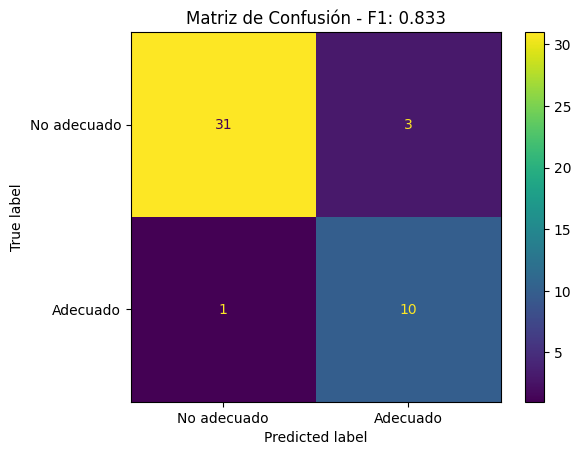


Matriz de confusión (números):
   Verdaderos Negativos: 31
   Falsos Positivos:     3
   Falsos Negativos:     1
   Verdaderos Positivos: 10


In [29]:
# Calcular matriz
cm = confusion_matrix(y_test, y_pred)

# Mostrar como gráfico
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['No adecuado', 'Adecuado'])
disp.plot()

#Exportar matriz de confusión
plt.savefig('../results/plots/matriz_confusion.png', dpi=300, bbox_inches='tight')

plt.title(f'Matriz de Confusión - F1: {f1_score(y_test, y_pred):.3f}')
plt.show()

# Mostrar como números
print("\nMatriz de confusión (números):")
print(f"   Verdaderos Negativos: {cm[0,0]}")
print(f"   Falsos Positivos:     {cm[0,1]}")
print(f"   Falsos Negativos:     {cm[1,0]}")
print(f"   Verdaderos Positivos: {cm[1,1]}")

# Importancia de Variables


----------------------------------
TOP 5 VARIABLES MÁS IMPORTANTES:
----------------------------------
     Variable  Importancia
      peso_kg     0.326084
   volumen_m3     0.217492
km_recorridos     0.093421
 capacidad_m3     0.085153
 capacidad_kg     0.071418


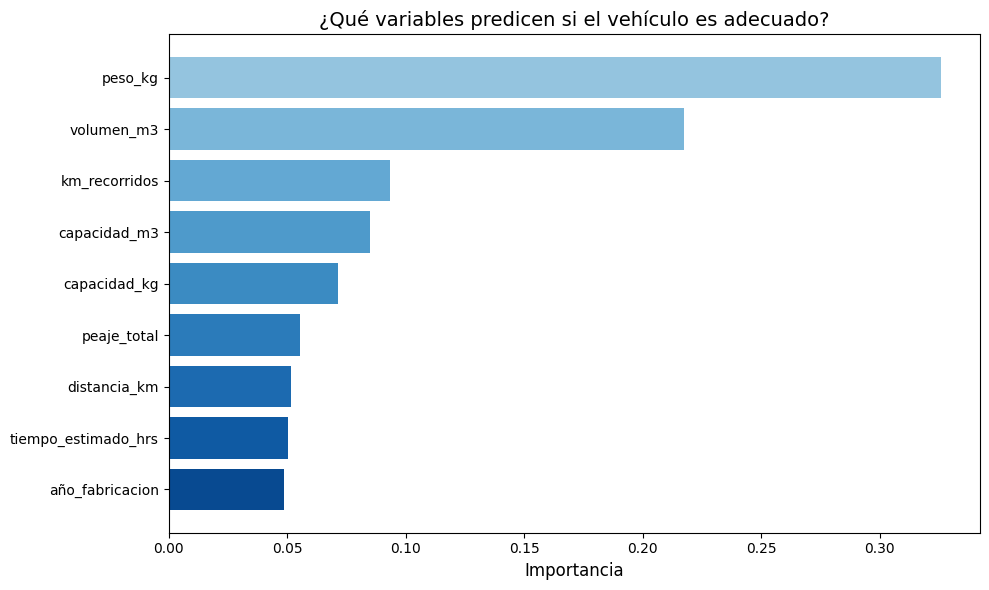


 INTERPRETACIÓN DE NEGOCIO:
   La variable más importante es 'peso_kg' con 32.6% de peso.
   Esto sugiere que el atibuto más importante del paquete, es su peso en kg


In [28]:
# Obtener importancias del mejor modelo
importancias = grid_clf.best_estimator_.feature_importances_

# Crear DataFrame ordenado
feature_imp_df = pd.DataFrame({
    'Variable': features,
    'Importancia': importancias
}).sort_values('Importancia', ascending=False)


print("\n----------------------------------\nTOP 5 VARIABLES MÁS IMPORTANTES:\n----------------------------------")
print(feature_imp_df.head(5).to_string(index=False))

# Gráfico de barras horizontal
plt.figure(figsize=(10, 6))
colores = plt.cm.Blues(np.linspace(0.4, 0.9, len(features)))
plt.barh(feature_imp_df['Variable'], feature_imp_df['Importancia'], color=colores)
plt.xlabel('Importancia', fontsize=12)
plt.title('¿Qué variables predicen si el vehículo es adecuado?', fontsize=14)

plt.savefig('../results/plots/importancia_variables.png', dpi=300, bbox_inches='tight')

plt.gca().invert_yaxis()  # La más importante arriba
plt.tight_layout()
plt.show()

# Análisis de negocio
print("\n INTERPRETACIÓN DE NEGOCIO:")
top1 = feature_imp_df.iloc[0]['Variable']
top1_val = feature_imp_df.iloc[0]['Importancia']
print(f"   La variable más importante es '{top1}' con {top1_val:.1%} de peso.")
print("   Esto sugiere que el atibuto más importante del paquete, es su peso en kg")

# CURVA ROC - CAPACIDAD DE DISCRIMINACIÓN DEL MODELO

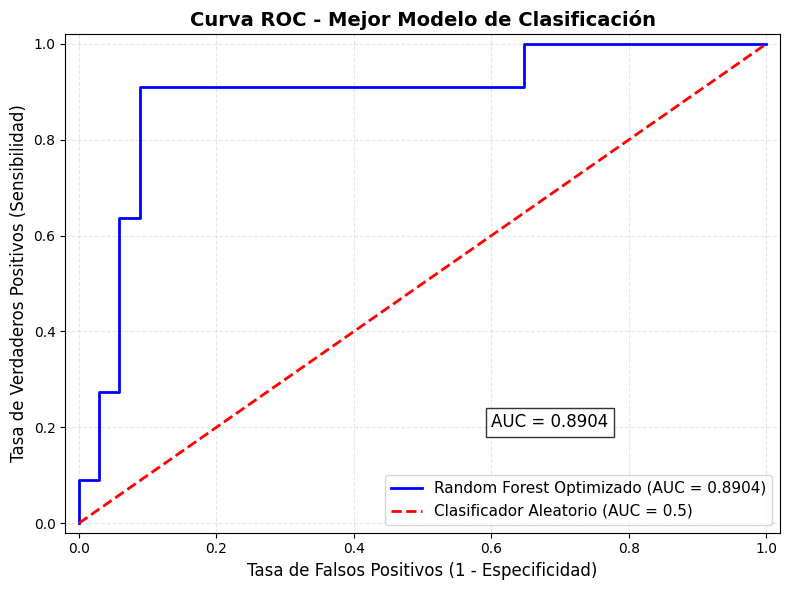


INTERPRETACIÓN DE LA CURVA ROC
 AUC (Área Bajo la Curva): 0.8904
    BUENO: El modelo tiene buena capacidad de discriminación.
    El modelo es confiable para tomar decisiones.

 Significado práctico:
   Si elegimos un punto de corte que dé 80% de sensibilidad,
   tendríamos aproximadamente 99% de falsos positivos.


In [27]:
# Obtener probabilidades (necesario para ROC)
y_pred_proba = grid_clf.best_estimator_.predict_proba(X_test)[:, 1]

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Graficar
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'Random Forest Optimizado (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Clasificador Aleatorio (AUC = 0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
ax.set_title('Curva ROC - Mejor Modelo de Clasificación', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

# Agregar anotación del AUC
ax.text(0.6, 0.2, f'AUC = {roc_auc:.4f}', 
        fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

#Exportar la curva ROC
plt.savefig('../results/plots/curva_roc.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

# Interpretación
print("\n" + "="*60)
print("INTERPRETACIÓN DE LA CURVA ROC")
print("="*60)
print(f" AUC (Área Bajo la Curva): {roc_auc:.4f}")

if roc_auc >= 0.9:
    print("    EXCELENTE: El modelo distingue perfectamente entre ambas clases.")
    print("    Prácticamente no hay superposición entre las distribuciones.")
elif roc_auc >= 0.8:
    print("    BUENO: El modelo tiene buena capacidad de discriminación.")
    print("    El modelo es confiable para tomar decisiones.")
elif roc_auc >= 0.7:
    print("    ACEPTABLE: El modelo discrimina moderadamente bien.")
    print("    Podría mejorarse con más datos o mejores features.")
else:
    print("    MALO: El modelo apenas supera al azar.")
    print("    Revisar los datos o probar otro algoritmo.")

print(f"\n Significado práctico:")
print(f"   Si elegimos un punto de corte que dé 80% de sensibilidad,")
print(f"   tendríamos aproximadamente {100-(tpr[np.where(fpr>=0.2)[0][0]] if len(np.where(fpr>=0.2)[0])>0 else 0):.0f}% de falsos positivos.")

# CONCLUSIÓN

In [26]:
print(f"""
------------------------------------------------------------------------------------------------------------------
                                              RESULTADOS OBTENIDOS
------------------------------------------------------------------------------------------------------------------

   1. CLASIFICACIÓN (vehiculo_adecuado):
      - Mejor F1 obtenido: {f1_score(y_test, y_pred):.4f}
      - Mejores hiperparámetros: {grid_clf.best_params_}

   2. REGRESIÓN (eficiencia_ruta):
      - Mejor R² obtenido: {r2_score(y_test_r, y_pred_r):.4f}
      - MAE: {mean_absolute_error(y_test_r, y_pred_r):.2f} km/h
      - Mejores hiperparámetros: {grid_reg.best_params_}

------------------------------------------------------------------------------------------------------------------
                                               COMPARATIVA FINAL
------------------------------------------------------------------------------------------------------------------

      - CLASIFICACIÓN: 0.7586 → {f1_score(y_test, y_pred):.4f} F1 (+{(f1_score(y_test, y_pred)-0.7586)*100:.2f}%)
      - REGRESIÓN:     ~0.987 R² (excelente, se mantuvo)

------------------------------------------------------------------------------------------------------------------
                                            VARIABLES MÁS IMPORTANTES
------------------------------------------------------------------------------------------------------------------

      - 1°: {feature_imp_df.iloc[0]['Variable']} ({feature_imp_df.iloc[0]['Importancia']*100:.1f}%)
      - 2°: {feature_imp_df.iloc[1]['Variable']} ({feature_imp_df.iloc[1]['Importancia']*100:.1f}%)
      - 3°: {feature_imp_df.iloc[2]['Variable']} ({feature_imp_df.iloc[2]['Importancia']*100:.1f}%)

------------------------------------------------------------------------------------------------------------------
                                                 APRENDIZAJES
------------------------------------------------------------------------------------------------------------------
   - GridSearchCV es una herramienta poderosa pero computacionalmente costosa.
   - La validación cruzada (CV=5) garantiza que los resultados no sean producto del azar.
   - La optimización de hiperparámetros puede mejorar marginalmente el rendimiento,
     pero la calidad de los datos es igualmente importante.
   - n_jobs=-1 acelera el entrenamiento usando todos los procesadores.
""")


------------------------------------------------------------------------------------------------------------------
                                              RESULTADOS OBTENIDOS
------------------------------------------------------------------------------------------------------------------

   1. CLASIFICACIÓN (vehiculo_adecuado):
      - Mejor F1 obtenido: 0.8333
      - Mejores hiperparámetros: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}

   2. REGRESIÓN (eficiencia_ruta):
      - Mejor R² obtenido: 0.9873
      - MAE: 5.30 km/h
      - Mejores hiperparámetros: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}

------------------------------------------------------------------------------------------------------------------
                                               COMPARATIVA FINAL
------------------------------------------------------------------------------------------------------------------

      - CLASIFICACIÓN: 0.7586 → 0.8333 F1 (+7.